In [1]:
!#pip install jinja2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import jinja2
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
RUTA_TABLAS = "TABLAS DOSR TARIFAS.xlsx"

SHEET_INVENTARIO = "INVENTARIO"
SHEET_LINEAS = "LINEASOFERTA"
SHEET_ACCOUNTS = "ACCOUNTS"
df_inventario = pd.read_excel(RUTA_TABLAS, sheet_name=SHEET_INVENTARIO)
df_lineas = pd.read_excel(RUTA_TABLAS, sheet_name=SHEET_LINEAS)
df_accounts = pd.read_excel(RUTA_TABLAS, sheet_name=SHEET_ACCOUNTS)

print("Inventario:", df_inventario.shape)
print("Lineas:", df_lineas.shape)
print("Accounts:", df_accounts.shape)

Inventario: (6302, 92)
Lineas: (4930, 177)
Accounts: (80, 16)


In [4]:
df_lineas = df_lineas.merge(
    df_accounts[["AccountName", "Ciudad"]],
    left_on="CreatedBy",
    right_on="AccountName",
    how="left"
)

df_lineas["Ciudad_Asesor"] = df_lineas["Ciudad"].fillna("SinSeleccionar")
df_lineas = df_lineas.drop(columns=["AccountName", "Ciudad"], errors="ignore")

df_lineas[["CreatedBy", "Ciudad_Asesor"]].head()

,CreatedBy,Ciudad_Asesor
0,Comercial4,Bogota
1,Comercial2,Medellin
2,Comercial2,Medellin
3,Comercial2,Medellin
4,Comercial2,Medellin


In [5]:
cols_inventario = [
    "Placa",
    "Chasis",
    "Referencia",
    "Marca",
    "Modelo",
    "UbicacionActual",
    "CalificacionFisica",
    "Kilometraje",
    "ClasificacionVenta",
    "TipoInventario",
    "PrecioMercado",
    "ValorFasecoldaGM",
    "FechaEntregaMoto",
    "FechaDisponible"
]

cols_lineas = [
    "FK_Placa",
    "Canal",
    "Ciudad_Asesor",
    "ContraOferta",
    "VlrTotalCompra",
    "FechaLegalizacion",
    "TotalPasivosActuales",
    "EstadoLegalizacion"
]

df_inv_sel = df_inventario[cols_inventario].copy()
df_lin_sel = df_lineas[cols_lineas].copy()

df_base = df_inv_sel.merge(
    df_lin_sel,
    left_on="Placa",
    right_on="FK_Placa",
    how="left"
)

df_base["FechaLegalizacion"] = pd.to_datetime(df_base["FechaLegalizacion"], errors="coerce")
df_base["FechaDisponible"] = pd.to_datetime(df_base["FechaDisponible"], errors="coerce")

print(df_base.shape)
df_base.head(2)

(6303, 22)


,Placa,Chasis,Referencia,Marca,Modelo,UbicacionActual,CalificacionFisica,Kilometraje,ClasificacionVenta,TipoInventario,PrecioMercado,ValorFasecoldaGM,FechaEntregaMoto,FechaDisponible,FK_Placa,Canal,Ciudad_Asesor,ContraOferta,VlrTotalCompra,FechaLegalizacion,TotalPasivosActuales,EstadoLegalizacion
0,ATA18E,9FKKE1375G2076906,CRYPTON [2] T115 MT 115CC,YAMAHA,"2,016.00",Neiva,1.00,"10,179.00",VENDIDA,VENDIDA,"5,250,000.00","3,400,000.00",2018-02-21,NaT,ATA18E,Compraventero,Bogota,"2,800,000.00","5,500,000.00",2024-11-30,"526,751.00",Si
1,FUG13E,9FLJDC1ZXHAH18220,BAJAJ PULSAR 135 LS MT 135CC,BAJAJ,"2,017.00",Bodega Cali,1.00,NaN,VENDIDA,VENDIDA,"3,800,000.00","3,400,000.00",2018-10-10,NaT,FUG13E,MotosDesensamble,Bogota,"1,299,600.00","3,800,000.00",2025-03-12,"1,568,385.00",Si


In [6]:
FECHA_CORTE = pd.Timestamp("2026-04-07")

df_base["PrecioVenta"] = np.select(
    [
        df_base["Canal"] == "Venta Directa",
        df_base["Canal"] == "MotosDesensamble",
        (df_base["Canal"] == "Compraventero") & (df_base["FechaLegalizacion"] < FECHA_CORTE),
        (df_base["Canal"] == "Compraventero") & (df_base["FechaLegalizacion"] >= FECHA_CORTE),
        df_base["Canal"] == "Aliados"
    ],
    [
        df_base["VlrTotalCompra"],
        df_base["ContraOferta"],
        df_base["ContraOferta"] + df_base["TotalPasivosActuales"],
        df_base["ContraOferta"],
        df_base["VlrTotalCompra"]
    ],
    default=np.nan
)

In [7]:
def _norm_ciudad(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = re.sub(r"\s+", " ", s)
    return s.upper()

HOMOLOGACION_CIUDAD_NORM = {
    _norm_ciudad("Armenia"): "Armenia",
    _norm_ciudad("BARRANQUILLA"): "Barranquilla",
    _norm_ciudad("Barranquilla"): "Barranquilla",
    _norm_ciudad("Barranquilla ruta 66"): "Barranquilla",
    _norm_ciudad("BUCARAMANGA"): "Bucaramanga",
    _norm_ciudad("Bucaramanga"): "Bucaramanga",
    _norm_ciudad("Bogota"): "Bogota",
    _norm_ciudad("Bodega 2 Bogota"): "Bogota",
    _norm_ciudad("Punto de Venta Bogota"): "Bogota",
    _norm_ciudad("Punto de venta Bogota"): "Bogota",
    _norm_ciudad("Bog 2R la Plaza"): "Bogota",
    _norm_ciudad("Bog 2R PDV"): "Bogota",
    _norm_ciudad("Bog AVL la 15"): "Bogota",
    _norm_ciudad("Cali"): "Cali",
    _norm_ciudad("Cali 7 de agosto"): "Cali",
    _norm_ciudad("Bodega Cali"): "Cali",
    _norm_ciudad("Bodega 2 Cali"): "Cali",
    _norm_ciudad("Calima"): "Cali",
    _norm_ciudad("Pradera"): "Cali",
    _norm_ciudad("CARTAGENA"): "Cartagena",
    _norm_ciudad("Cartagena"): "Cartagena",
    _norm_ciudad("Punto de venta Cartagena"): "Cartagena",
    _norm_ciudad("Ibague"): "Ibague",
    _norm_ciudad("MEDELLIN"): "Medellin",
    _norm_ciudad("Medellin"): "Medellin",
    _norm_ciudad("Serviautec"): "Medellin",
    _norm_ciudad("Dos serviautec"): "Medellin",
    _norm_ciudad("Medellin DosR"): "Medellin",
    _norm_ciudad("Neiva"): "Neiva",
    _norm_ciudad("Pereira"): "Pereira",
    _norm_ciudad("SANTANDER DE QUILICHAO"): "Santander de Quilichao",
    _norm_ciudad("Santander de Quilichao"): "Santander de Quilichao",
    _norm_ciudad("Bodega Santa Marta"): "Santa Marta",
}

def homologar_ciudad(valor):
    if valor is None or str(valor).strip() == "":
        return "SinSeleccionar"
    return HOMOLOGACION_CIUDAD_NORM.get(_norm_ciudad(valor), str(valor).strip())

In [8]:
!pip install db-dtypes


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
from google.cloud import bigquery
from google.oauth2 import service_account

BQ_PROJECT = "lucia-stg"  # ajusta si en tu config tienes otro project para el cliente
BQ_CREDENTIALS_FILE = "/Users/juanesteban/Documents/Modelo de optimizacion inventario avalogic /Produccion/bigqery.json"  # CAMBIAR

def fetch_runt_by_chasis(lista_chasis):
    if not lista_chasis:
        return pd.DataFrame(columns=["CHASIS", "MARCA", "LINEA"])

    credentials = service_account.Credentials.from_service_account_file(
        BQ_CREDENTIALS_FILE,
        scopes=["https://www.googleapis.com/auth/cloud-platform"]
    )

    client = bigquery.Client(credentials=credentials, project=BQ_PROJECT)

    query = """
        SELECT
            chasis AS CHASIS,
            r.MARCA,
            r.LINEA
        FROM UNNEST(@lista_chasis) AS chasis
        LEFT JOIN `lucia-stg.runt.RUNT` r
            ON r.CHASIS = chasis
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("lista_chasis", "STRING", lista_chasis)
        ]
    )

    return client.query(query, job_config=job_config).to_dataframe()

In [10]:
import db_dtypes

lista_chasis = (
    df_base["Chasis"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

df_runt = fetch_runt_by_chasis(lista_chasis)

print("Chasis consultados:", len(lista_chasis))
print("Registros RUNT:", df_runt.shape)
df_runt.head()

/Users/juanesteban/Documents/DosR/Automatizacion de tarifas/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Chasis consultados: 6293
Registros RUNT: (6596, 3)


,CHASIS,MARCA,LINEA
0,9FSBE4EN2GC133957,None,None
1,9FLKAGBA7HCB07675,KYMCO,KYMCO TWIST
2,9FLA18AZ0HDF49636,BAJAJ,BOXER CT 100
3,9FLA18AZ0HDF49636,BAJAJ,BOXER CT 100
4,9FLA66DZ0HAE05250,BAJAJ,PULSAR NS 150


In [11]:
df_base = df_base.merge(
    df_runt,
    left_on="Chasis",
    right_on="CHASIS",
    how="left"
)

df_base = df_base.drop(columns=["CHASIS"], errors="ignore")
df_base = df_base.rename(columns={"MARCA": "MARCA_RUNT", "LINEA": "LINEA_RUNT"})

df_base[["Placa", "Chasis", "Marca", "Referencia", "MARCA_RUNT", "LINEA_RUNT"]].head(10)

,Placa,Chasis,Marca,Referencia,MARCA_RUNT,LINEA_RUNT
0,ATA18E,9FKKE1375G2076906,YAMAHA,CRYPTON [2] T115 MT 115CC,None,None
1,FUG13E,9FLJDC1ZXHAH18220,BAJAJ,BAJAJ PULSAR 135 LS MT 135CC,BAJAJ,PULSAR 135 LS PRO
2,FCO42E,9FLU62012HCK53060,KYMCO,AGILITY DIGITAL 3.0 AT 125CC,KYMCO,AGILITY DGTL 125 3.0
3,ASS46E,9FSBE4EN2GC133957,SUZUKI,VIVA R STYLE MT 115CC,None,None
4,UAI92D,9FKKE2015F2105647,YAMAHA,BWS X MOTARD [YW 125X] AT 125CC,None,None
5,TFS60D,9FLKNGJA4GCE00034,KYMCO,ROCKET 125 AT 125CC,KYMCO,ROCKET 125
6,TFS60D,9FLKNGJA4GCE00034,KYMCO,ROCKET 125 AT 125CC,KYMCO,ROCKET 125
7,IAS39D,9FKKE1999F2080061,YAMAHA,YBR 125 MT 125CC,None,None
8,XUK59D,9FLA36FZ4GBF65632,BAJAJ,BAJAJ PULSAR 200 NS MT 200CC,BAJAJ,PULSAR 200 NS PULSARMANIA
9,XUK59D,9FLA36FZ4GBF65632,BAJAJ,BAJAJ PULSAR 200 NS MT 200CC,BAJAJ,PULSAR 200 NS PULSARMANIA


In [12]:
resumen_runt = pd.Series({
    "filas_base": len(df_base),
    "placas_unicas": df_base["Placa"].nunique(),
    "chasis_unicos": df_base["Chasis"].nunique(),
    "con_LINEA_RUNT": df_base["LINEA_RUNT"].notna().sum(),
    "sin_LINEA_RUNT": df_base["LINEA_RUNT"].isna().sum(),
    "pct_con_LINEA_RUNT": df_base["LINEA_RUNT"].notna().mean()
})

resumen_runt

filas_base           6,606.00
placas_unicas        6,302.00
chasis_unicos        6,293.00
con_LINEA_RUNT       6,422.00
sin_LINEA_RUNT         184.00
pct_con_LINEA_RUNT       0.97
dtype: float64

In [13]:
df_analisis = df_base.copy()

df_analisis["EstadoLegalizacion_norm"] = (
    df_analisis["EstadoLegalizacion"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_analisis["dias_diff"] = (
    df_analisis["FechaLegalizacion"] - df_analisis["FechaDisponible"]
).dt.days.abs()

df_analisis["Ciudad_Asesor"] = df_analisis["Ciudad_Asesor"].fillna("SinSeleccionar")
df_analisis["ciudad_add"] = np.where(
    df_analisis["Ciudad_Asesor"] == "SinSeleccionar",
    df_analisis["UbicacionActual"],
    df_analisis["Ciudad_Asesor"]
)
df_analisis["ciudad_homologada"] = df_analisis["ciudad_add"].apply(homologar_ciudad)

df_analisis = df_analisis[
    df_analisis["FechaLegalizacion"].notna() &
    df_analisis["FechaDisponible"].notna() &
    (df_analisis["Canal"] != "MotosDesensamble") &
    (df_analisis["EstadoLegalizacion_norm"] == "SI") &
    df_analisis["LINEA_RUNT"].notna()
].copy()

# limpieza razonable
df_analisis["CalificacionFisica"] = pd.to_numeric(df_analisis["CalificacionFisica"], errors="coerce")
df_analisis["PrecioMercado"] = pd.to_numeric(df_analisis["PrecioMercado"], errors="coerce")
df_analisis["PrecioVenta"] = pd.to_numeric(df_analisis["PrecioVenta"], errors="coerce")
df_analisis.loc[~df_analisis["dias_diff"].between(0, 365*3), "dias_diff"] = np.nan

print(df_analisis.shape)
df_analisis[["Placa", "Canal", "LINEA_RUNT", "ciudad_homologada", "dias_diff"]].head()

(4104, 29)


,Placa,Canal,LINEA_RUNT,ciudad_homologada,dias_diff
14,LIC72E,Compraventero,KYMCO TWIST,Bogota,6.00
16,XFJ34D,Compraventero,DISCOVER 150 ST,Bogota,13.00
17,BGN23E,Compraventero,PULSAR 180 UG PRO,Bogota,20.00
18,BGN23E,Compraventero,PULSAR 180 UG PRO,Bogota,20.00
19,AFL86E,Venta Directa,JETIX 125,Ibague,49.00


In [14]:
df_con_cv = df_analisis.copy()

df_sin_cv = df_analisis[
    df_analisis["Canal"] != "Compraventero"
].copy()

print("Ventas con compraventero:", len(df_con_cv))
print("Ventas sin compraventero:", len(df_sin_cv))
print("Ventas compraventero:", (df_analisis["Canal"] == "Compraventero").sum())
print("Peso compraventero:", round((df_analisis["Canal"] == "Compraventero").mean() * 100, 2), "%")

Ventas con compraventero: 4104
Ventas sin compraventero: 1446
Ventas compraventero: 2658
Peso compraventero: 64.77 %


In [16]:
def resumen_general(df_):
    return pd.Series({
        "ventas": len(df_),
        "placas_unicas": df_["Placa"].nunique(),
        "lineas_runt_unicas": df_["LINEA_RUNT"].nunique(),
        "ciudades_unicas": df_["ciudad_homologada"].nunique(),
        "calif_promedio": df_["CalificacionFisica"].mean(),
        "calif_mediana": df_["CalificacionFisica"].median(),
        "dias_promedio": df_["dias_diff"].mean(),
        "dias_mediana": df_["dias_diff"].median(),
        "precio_mercado_prom": df_["PrecioMercado"].mean(),
        "precio_mercado_med": df_["PrecioMercado"].median(),
        "precio_venta_prom": df_["PrecioVenta"].mean(),
        "precio_venta_med": df_["PrecioVenta"].median(),
    })

comparativo_general = pd.concat(
    {
        "Con_Compraventero": resumen_general(df_con_cv),
        "Sin_Compraventero": resumen_general(df_sin_cv),
    },
    axis=1
)

comparativo_general

,Con_Compraventero,Sin_Compraventero
ventas,"4,104.00","1,446.00"
placas_unicas,"3,960.00","1,415.00"
lineas_runt_unicas,311.00,220.00
ciudades_unicas,21.00,12.00
calif_promedio,20.97,25.17
calif_mediana,4.00,4.29
dias_promedio,45.48,43.73
dias_mediana,25.00,23.00
precio_mercado_prom,"6,378,685.12","6,719,744.05"
precio_mercado_med,"6,300,000.00","6,653,000.00"


In [17]:
comparativo = comparativo_general.T.copy()

base = comparativo.loc["Con_Compraventero"]

for col in comparativo.columns:
    comparativo[f"{col}_vs_base_%"] = np.where(
        base[col] != 0,
        (comparativo[col] / base[col] - 1) * 100,
        np.nan
    )

comparativo

,ventas,placas_unicas,lineas_runt_unicas,ciudades_unicas,calif_promedio,calif_mediana,dias_promedio,dias_mediana,precio_mercado_prom,precio_mercado_med,precio_venta_prom,precio_venta_med,ventas_vs_base_%,placas_unicas_vs_base_%,lineas_runt_unicas_vs_base_%,ciudades_unicas_vs_base_%,calif_promedio_vs_base_%,calif_mediana_vs_base_%,dias_promedio_vs_base_%,dias_mediana_vs_base_%,precio_mercado_prom_vs_base_%,precio_mercado_med_vs_base_%,precio_venta_prom_vs_base_%,precio_venta_med_vs_base_%
Con_Compraventero,"4,104.00","3,960.00",311.00,21.00,20.97,4.00,45.48,25.00,"6,378,685.12","6,300,000.00","4,663,386.95","4,449,327.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sin_Compraventero,"1,446.00","1,415.00",220.00,12.00,25.17,4.29,43.73,23.00,"6,719,744.05","6,653,000.00","5,964,070.89","5,838,175.00",-64.77,-64.27,-29.26,-42.86,20.02,7.25,-3.84,-8.00,5.35,5.60,27.89,31.21


In [18]:
def _pct(x, p):
    x = pd.Series(x).dropna().to_numpy()
    if x.size == 0:
        return np.nan
    return float(np.percentile(x, p))

def tabla_estadisticos_local(df_, group_cols):
    total_base = len(df_)

    agg = (
        df_
        .groupby(group_cols)
        .agg(
            Cantidad=("dias_diff", "size"),
            P25_dias=("dias_diff", lambda x: _pct(x, 25)),
            P50_dias=("dias_diff", lambda x: _pct(x, 50)),
            P75_dias=("dias_diff", lambda x: _pct(x, 75)),
            P90_dias=("dias_diff", lambda x: _pct(x, 90)),
            Promedio_dias=("dias_diff", "mean"),
            Promedio_CalificacionFisica=("CalificacionFisica", "mean"),
            Promedio_PrecioMercado=("PrecioMercado", "mean"),
            Promedio_PrecioVenta=("PrecioVenta", "mean"),
        )
        .reset_index()
        .sort_values("Cantidad", ascending=False)
    )

    agg["%Del_total"] = np.where(total_base > 0, agg["Cantidad"] / total_base, 0)
    agg["%Del_acumulado"] = agg["%Del_total"].cumsum()
    agg["Ingreso_por_dia"] = np.where(
        agg["P50_dias"] > 0,
        agg["Promedio_PrecioVenta"] / agg["P50_dias"],
        np.nan
    )
    return agg

In [19]:
stats_linea_con = tabla_estadisticos_local(df_con_cv, ["LINEA_RUNT"])
stats_linea_sin = tabla_estadisticos_local(df_sin_cv, ["LINEA_RUNT"])

stats_linea_con.head(10)

,LINEA_RUNT,Cantidad,P25_dias,P50_dias,P75_dias,P90_dias,Promedio_dias,Promedio_CalificacionFisica,Promedio_PrecioMercado,Promedio_PrecioVenta,%Del_total,%Del_acumulado,Ingreso_por_dia
244,RAIDER 125,287,8.00,20.00,40.00,86.80,34.29,4.44,"6,744,587.82","5,485,875.30",0.07,0.07,"274,293.76"
53,BOMBER 125,122,17.00,32.00,52.50,101.60,47.22,3.95,"4,593,805.14","2,757,335.07",0.03,0.10,"86,166.72"
39,APACHE RTR 160 4V XCONNECT,111,10.50,24.00,51.50,107.00,42.94,4.21,"7,886,008.88","6,155,031.17",0.03,0.13,"256,459.63"
75,CB125F,108,12.00,26.00,60.25,101.90,43.79,4.21,"6,106,619.49","4,565,474.26",0.03,0.15,"175,595.16"
26,AK125NKD EIII,96,4.75,10.00,21.00,32.50,15.35,4.84,"4,328,040.10","3,702,947.35",0.02,0.18,"370,294.74"
168,MRX125 TK,93,17.00,34.00,62.00,89.20,52.44,4.14,"7,396,758.05","5,212,418.10",0.02,0.20,"153,306.41"
283,VENOM 14,91,20.50,60.00,106.50,161.00,77.00,3.97,"6,957,495.26","4,031,865.99",0.02,0.22,"67,197.77"
183,NITRO 125,91,22.50,56.00,104.00,167.00,78.78,3.43,"5,120,780.22","3,408,263.48",0.02,0.24,"60,861.85"
162,MRX125,89,16.00,38.00,64.00,99.20,52.97,3.24,"6,627,957.24","4,004,049.89",0.02,0.27,"105,369.73"
169,MRX150,81,15.00,27.00,50.00,159.00,47.49,3.19,"7,113,628.54","4,434,588.77",0.02,0.28,"164,244.03"


In [20]:
stats_linea_ciudad_con = tabla_estadisticos_local(df_con_cv, ["LINEA_RUNT", "ciudad_homologada"])
stats_linea_ciudad_sin = tabla_estadisticos_local(df_sin_cv, ["LINEA_RUNT", "ciudad_homologada"])

stats_linea_ciudad_con.head(10)

,LINEA_RUNT,ciudad_homologada,Cantidad,P25_dias,P50_dias,P75_dias,P90_dias,Promedio_dias,Promedio_CalificacionFisica,Promedio_PrecioMercado,Promedio_PrecioVenta,%Del_total,%Del_acumulado,Ingreso_por_dia
713,RAIDER 125,Bogota,148,7.00,15.50,33.00,61.50,27.26,4.31,"6,729,274.85","5,464,459.27",0.04,0.04,"352,545.76"
246,CB125F,Bogota,100,11.00,25.50,54.25,101.30,42.39,4.22,"6,116,490.01","4,569,756.48",0.02,0.06,"179,206.14"
719,RAIDER 125,Medellin,81,9.00,21.00,39.00,88.00,34.07,4.89,"6,802,918.74","5,421,229.03",0.02,0.08,"258,153.76"
124,APACHE RTR 160 4V XCONNECT,Bogota,74,10.75,24.00,46.50,74.20,35.11,4.01,"7,886,175.48","6,199,571.92",0.02,0.10,"258,315.50"
168,BOMBER 125,Bogota,59,16.00,31.00,51.00,90.80,46.25,3.87,"4,482,579.59","2,956,113.81",0.01,0.11,"95,358.51"
553,NITRO 125,Bogota,49,21.00,51.00,99.00,132.20,63.78,3.53,"5,136,285.71","3,597,481.33",0.01,0.12,"70,538.85"
500,MRX150,Bogota,45,15.00,24.00,34.00,68.20,34.69,3.02,"6,921,553.60","4,171,531.19",0.01,0.14,"173,813.80"
454,MRX ARIZONA,Bogota,45,10.00,21.00,51.00,106.00,41.07,4.15,"9,857,885.12","7,590,919.33",0.01,0.15,"361,472.35"
81,AK125NKD EIII,Bogota,44,3.00,8.50,14.00,21.70,10.11,4.12,"4,332,578.10","3,542,831.98",0.01,0.16,"416,803.76"
827,VENOM 14,Bogota,44,20.75,70.50,101.25,136.50,69.95,4.28,"6,979,601.76","3,984,762.14",0.01,0.17,"56,521.45"


In [21]:
def resumen_cobertura(df_stats_linea, df_stats_linea_ciudad, nombre):
    return pd.Series({
        "escenario": nombre,
        "lineas_con_1+": (df_stats_linea["Cantidad"] >= 1).sum(),
        "lineas_con_3+": (df_stats_linea["Cantidad"] >= 3).sum(),
        "lineas_con_5+": (df_stats_linea["Cantidad"] >= 5).sum(),
        "linea_ciudad_con_1+": (df_stats_linea_ciudad["Cantidad"] >= 1).sum(),
        "linea_ciudad_con_3+": (df_stats_linea_ciudad["Cantidad"] >= 3).sum(),
        "linea_ciudad_con_5+": (df_stats_linea_ciudad["Cantidad"] >= 5).sum(),
    })

cobertura = pd.DataFrame([
    resumen_cobertura(stats_linea_con, stats_linea_ciudad_con, "Con_Compraventero"),
    resumen_cobertura(stats_linea_sin, stats_linea_ciudad_sin, "Sin_Compraventero"),
])

cobertura

,escenario,lineas_con_1+,lineas_con_3+,lineas_con_5+,linea_ciudad_con_1+,linea_ciudad_con_3+,linea_ciudad_con_5+
0,Con_Compraventero,311,198,152,904,304,179
1,Sin_Compraventero,220,123,85,498,134,71


In [22]:
lineas_con = set(stats_linea_con["LINEA_RUNT"])
lineas_sin = set(stats_linea_sin["LINEA_RUNT"])

lineas_perdidas = sorted(list(lineas_con - lineas_sin))

print("Líneas RUNT que desaparecen al excluir compraventero:", len(lineas_perdidas))
pd.DataFrame({"LINEA_RUNT_perdida": lineas_perdidas}).head(50)

Líneas RUNT que desaparecen al excluir compraventero: 91


,LINEA_RUNT_perdida
0,ADVANCE 110
1,ADVANCE R
2,AGILITY ALL NEW
3,AGILITY DIGITAL 125
4,AGILITY DIGITAL 125 2.0
5,AK100NV EIII
6,AK300DS6
7,AVANTI 3.0
8,BLACK
9,BOLD 125 PRO


In [23]:
stats_linea_ciudad_con["key"] = (
    stats_linea_ciudad_con["LINEA_RUNT"].astype(str) + " | " +
    stats_linea_ciudad_con["ciudad_homologada"].astype(str)
)

stats_linea_ciudad_sin["key"] = (
    stats_linea_ciudad_sin["LINEA_RUNT"].astype(str) + " | " +
    stats_linea_ciudad_sin["ciudad_homologada"].astype(str)
)

combos_con = set(stats_linea_ciudad_con["key"])
combos_sin = set(stats_linea_ciudad_sin["key"])

combos_perdidos = sorted(list(combos_con - combos_sin))

print("Combos línea-ciudad perdidos:", len(combos_perdidos))
pd.DataFrame({"combo_perdido": combos_perdidos}).head(50)

Combos línea-ciudad perdidos: 406


,combo_perdido
0,180S | Cali
1,180S | Neiva
2,ADVANCE 110 | Bogota
3,ADVANCE 110 | Ibague
4,ADVANCE 110 | Medellin
5,ADVANCE 110 | Neiva
6,ADVANCE R 125 TK | Bogota
7,ADVANCE R 125 TK | Medellin
8,ADVANCE R 125 | Bogota
9,ADVANCE R 125 | Medellin


In [24]:
top_lineas = (
    df_con_cv["LINEA_RUNT"]
    .value_counts()
    .head(15)
    .index
    .tolist()
)

rows = []

for linea in top_lineas:
    a = df_con_cv[df_con_cv["LINEA_RUNT"] == linea]
    b = df_sin_cv[df_sin_cv["LINEA_RUNT"] == linea]

    rows.append({
        "LINEA_RUNT": linea,
        "Ventas_con_cv": len(a),
        "Ventas_sin_cv": len(b),
        "Perdida_ventas": len(a) - len(b),
        "Pct_perdida_ventas": ((len(a) - len(b)) / len(a) * 100) if len(a) else np.nan,
        "P50_dias_con_cv": a["dias_diff"].median(),
        "P50_dias_sin_cv": b["dias_diff"].median(),
        "Dif_P50_dias": b["dias_diff"].median() - a["dias_diff"].median(),
        "Calif_med_con_cv": a["CalificacionFisica"].median(),
        "Calif_med_sin_cv": b["CalificacionFisica"].median(),
        "Dif_Calif_med": b["CalificacionFisica"].median() - a["CalificacionFisica"].median(),
        "PrecioVenta_med_con_cv": a["PrecioVenta"].median(),
        "PrecioVenta_med_sin_cv": b["PrecioVenta"].median(),
        "Dif_PrecioVenta_med": b["PrecioVenta"].median() - a["PrecioVenta"].median(),
    })

impacto_top_lineas = pd.DataFrame(rows).sort_values("Perdida_ventas", ascending=False)
impacto_top_lineas

,LINEA_RUNT,Ventas_con_cv,Ventas_sin_cv,Perdida_ventas,Pct_perdida_ventas,P50_dias_con_cv,P50_dias_sin_cv,Dif_P50_dias,Calif_med_con_cv,Calif_med_sin_cv,Dif_Calif_med,PrecioVenta_med_con_cv,PrecioVenta_med_sin_cv,Dif_PrecioVenta_med
0,RAIDER 125,287,159,128,44.60,20.00,17.00,-3.00,4.28,4.38,0.10,"5,638,255.00","6,025,000.00","386,745.00"
1,BOMBER 125,122,34,88,72.13,32.00,44.50,12.50,4.00,4.17,0.17,"2,850,000.00","3,940,000.00","1,090,000.00"
3,CB125F,108,21,87,80.56,26.00,16.00,-10.00,4.26,4.22,-0.04,"4,500,000.00","5,400,000.00","900,000.00"
8,MRX125,89,10,79,88.76,38.00,41.50,3.50,3.00,4.00,1.00,"4,000,000.00","6,195,500.00","2,195,500.00"
5,MRX125 TK,93,15,78,83.87,34.00,54.00,20.00,4.10,4.32,0.22,"5,229,250.00","6,800,000.00","1,570,750.00"
9,MRX150,81,6,75,92.59,27.00,32.00,5.00,3.00,3.00,0.00,"4,438,400.00","6,278,750.00","1,840,350.00"
6,VENOM 14,91,23,68,74.73,60.00,72.00,12.00,4.00,4.38,0.38,"3,900,000.00","5,440,000.00","1,540,000.00"
10,ECO DELUXE CW,79,11,68,86.08,14.00,10.00,-4.00,4.21,4.40,0.19,"3,843,400.00","4,200,000.00","356,600.00"
7,NITRO 125,91,29,62,68.13,56.00,54.00,-2.00,3.70,4.06,0.36,"3,170,000.00","4,700,000.00","1,530,000.00"
2,APACHE RTR 160 4V XCONNECT,111,56,55,49.55,24.00,23.00,-1.00,4.03,4.29,0.26,"6,250,000.00","7,000,000.00","750,000.00"


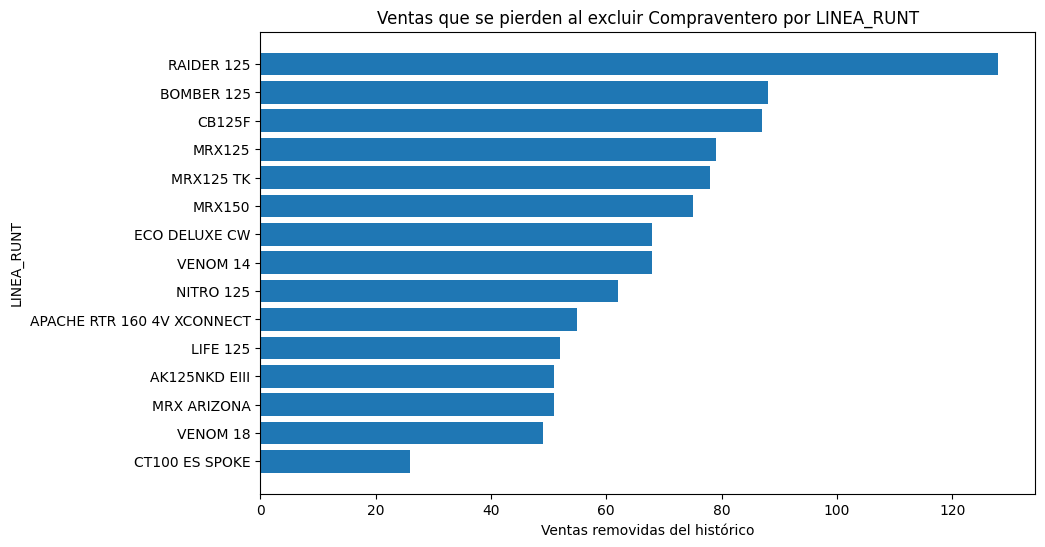

In [25]:
tmp = impacto_top_lineas.sort_values("Perdida_ventas", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(tmp["LINEA_RUNT"], tmp["Perdida_ventas"])
plt.title("Ventas que se pierden al excluir Compraventero por LINEA_RUNT")
plt.xlabel("Ventas removidas del histórico")
plt.ylabel("LINEA_RUNT")
plt.show()

In [26]:
sensibilidad_rotacion = impacto_top_lineas.copy()
sensibilidad_rotacion["Abs_Dif_P50_dias"] = sensibilidad_rotacion["Dif_P50_dias"].abs()

sensibilidad_rotacion.sort_values("Abs_Dif_P50_dias", ascending=False).head(15)

,LINEA_RUNT,Ventas_con_cv,Ventas_sin_cv,Perdida_ventas,Pct_perdida_ventas,P50_dias_con_cv,P50_dias_sin_cv,Dif_P50_dias,Calif_med_con_cv,Calif_med_sin_cv,Dif_Calif_med,PrecioVenta_med_con_cv,PrecioVenta_med_sin_cv,Dif_PrecioVenta_med,Abs_Dif_P50_dias
14,VENOM 18,67,18,49,73.13,59.00,97.50,38.50,4.00,4.00,0.00,"4,700,000.00","6,000,000.00","1,300,000.00",38.50
5,MRX125 TK,93,15,78,83.87,34.00,54.00,20.00,4.10,4.32,0.22,"5,229,250.00","6,800,000.00","1,570,750.00",20.00
12,LIFE 125,72,20,52,72.22,52.00,71.50,19.50,4.00,4.00,0.00,"3,600,875.50","5,323,500.00","1,722,624.50",19.50
1,BOMBER 125,122,34,88,72.13,32.00,44.50,12.50,4.00,4.17,0.17,"2,850,000.00","3,940,000.00","1,090,000.00",12.50
6,VENOM 14,91,23,68,74.73,60.00,72.00,12.00,4.00,4.38,0.38,"3,900,000.00","5,440,000.00","1,540,000.00",12.00
3,CB125F,108,21,87,80.56,26.00,16.00,-10.00,4.26,4.22,-0.04,"4,500,000.00","5,400,000.00","900,000.00",10.00
11,MRX ARIZONA,78,27,51,65.38,24.00,34.00,10.00,4.29,4.29,0.00,"7,545,250.00","9,272,850.00","1,727,600.00",10.00
9,MRX150,81,6,75,92.59,27.00,32.00,5.00,3.00,3.00,0.00,"4,438,400.00","6,278,750.00","1,840,350.00",5.00
10,ECO DELUXE CW,79,11,68,86.08,14.00,10.00,-4.00,4.21,4.40,0.19,"3,843,400.00","4,200,000.00","356,600.00",4.00
8,MRX125,89,10,79,88.76,38.00,41.50,3.50,3.00,4.00,1.00,"4,000,000.00","6,195,500.00","2,195,500.00",3.50


In [27]:
sensibilidad_calif = impacto_top_lineas.copy()
sensibilidad_calif["Abs_Dif_Calif_med"] = sensibilidad_calif["Dif_Calif_med"].abs()

sensibilidad_calif.sort_values("Abs_Dif_Calif_med", ascending=False).head(15)

,LINEA_RUNT,Ventas_con_cv,Ventas_sin_cv,Perdida_ventas,Pct_perdida_ventas,P50_dias_con_cv,P50_dias_sin_cv,Dif_P50_dias,Calif_med_con_cv,Calif_med_sin_cv,Dif_Calif_med,PrecioVenta_med_con_cv,PrecioVenta_med_sin_cv,Dif_PrecioVenta_med,Abs_Dif_Calif_med
8,MRX125,89,10,79,88.76,38.00,41.50,3.50,3.00,4.00,1.00,"4,000,000.00","6,195,500.00","2,195,500.00",1.00
6,VENOM 14,91,23,68,74.73,60.00,72.00,12.00,4.00,4.38,0.38,"3,900,000.00","5,440,000.00","1,540,000.00",0.38
7,NITRO 125,91,29,62,68.13,56.00,54.00,-2.00,3.70,4.06,0.36,"3,170,000.00","4,700,000.00","1,530,000.00",0.36
2,APACHE RTR 160 4V XCONNECT,111,56,55,49.55,24.00,23.00,-1.00,4.03,4.29,0.26,"6,250,000.00","7,000,000.00","750,000.00",0.26
5,MRX125 TK,93,15,78,83.87,34.00,54.00,20.00,4.10,4.32,0.22,"5,229,250.00","6,800,000.00","1,570,750.00",0.22
10,ECO DELUXE CW,79,11,68,86.08,14.00,10.00,-4.00,4.21,4.40,0.19,"3,843,400.00","4,200,000.00","356,600.00",0.19
1,BOMBER 125,122,34,88,72.13,32.00,44.50,12.50,4.00,4.17,0.17,"2,850,000.00","3,940,000.00","1,090,000.00",0.17
0,RAIDER 125,287,159,128,44.60,20.00,17.00,-3.00,4.28,4.38,0.10,"5,638,255.00","6,025,000.00","386,745.00",0.10
3,CB125F,108,21,87,80.56,26.00,16.00,-10.00,4.26,4.22,-0.04,"4,500,000.00","5,400,000.00","900,000.00",0.04
4,AK125NKD EIII,96,45,51,53.12,10.00,9.00,-1.00,4.39,4.43,0.04,"3,675,000.00","3,802,000.00","127,000.00",0.04


In [28]:
sensibilidad_precio = impacto_top_lineas.copy()
sensibilidad_precio["Abs_Dif_PrecioVenta_med"] = sensibilidad_precio["Dif_PrecioVenta_med"].abs()

sensibilidad_precio.sort_values("Abs_Dif_PrecioVenta_med", ascending=False).head(15)

,LINEA_RUNT,Ventas_con_cv,Ventas_sin_cv,Perdida_ventas,Pct_perdida_ventas,P50_dias_con_cv,P50_dias_sin_cv,Dif_P50_dias,Calif_med_con_cv,Calif_med_sin_cv,Dif_Calif_med,PrecioVenta_med_con_cv,PrecioVenta_med_sin_cv,Dif_PrecioVenta_med,Abs_Dif_PrecioVenta_med
8,MRX125,89,10,79,88.76,38.00,41.50,3.50,3.00,4.00,1.00,"4,000,000.00","6,195,500.00","2,195,500.00","2,195,500.00"
9,MRX150,81,6,75,92.59,27.00,32.00,5.00,3.00,3.00,0.00,"4,438,400.00","6,278,750.00","1,840,350.00","1,840,350.00"
11,MRX ARIZONA,78,27,51,65.38,24.00,34.00,10.00,4.29,4.29,0.00,"7,545,250.00","9,272,850.00","1,727,600.00","1,727,600.00"
12,LIFE 125,72,20,52,72.22,52.00,71.50,19.50,4.00,4.00,0.00,"3,600,875.50","5,323,500.00","1,722,624.50","1,722,624.50"
5,MRX125 TK,93,15,78,83.87,34.00,54.00,20.00,4.10,4.32,0.22,"5,229,250.00","6,800,000.00","1,570,750.00","1,570,750.00"
6,VENOM 14,91,23,68,74.73,60.00,72.00,12.00,4.00,4.38,0.38,"3,900,000.00","5,440,000.00","1,540,000.00","1,540,000.00"
7,NITRO 125,91,29,62,68.13,56.00,54.00,-2.00,3.70,4.06,0.36,"3,170,000.00","4,700,000.00","1,530,000.00","1,530,000.00"
14,VENOM 18,67,18,49,73.13,59.00,97.50,38.50,4.00,4.00,0.00,"4,700,000.00","6,000,000.00","1,300,000.00","1,300,000.00"
1,BOMBER 125,122,34,88,72.13,32.00,44.50,12.50,4.00,4.17,0.17,"2,850,000.00","3,940,000.00","1,090,000.00","1,090,000.00"
3,CB125F,108,21,87,80.56,26.00,16.00,-10.00,4.26,4.22,-0.04,"4,500,000.00","5,400,000.00","900,000.00","900,000.00"


In [29]:
def resumen_ciudad(df_, nombre):
    return (
        df_
        .groupby("ciudad_homologada")
        .agg(
            ventas=("Placa", "count"),
            lineas=("LINEA_RUNT", "nunique"),
            p50_dias=("dias_diff", "median"),
            calif_mediana=("CalificacionFisica", "median"),
            precio_venta_mediano=("PrecioVenta", "median"),
        )
        .reset_index()
        .assign(escenario=nombre)
    )

ciudad_con = resumen_ciudad(df_con_cv, "Con_Compraventero")
ciudad_sin = resumen_ciudad(df_sin_cv, "Sin_Compraventero")

comparativo_ciudad = ciudad_con.merge(
    ciudad_sin,
    on="ciudad_homologada",
    how="outer",
    suffixes=("_con", "_sin")
)

comparativo_ciudad["dif_ventas"] = comparativo_ciudad["ventas_con"] - comparativo_ciudad["ventas_sin"]
comparativo_ciudad["dif_lineas"] = comparativo_ciudad["lineas_con"] - comparativo_ciudad["lineas_sin"]
comparativo_ciudad["dif_p50_dias"] = comparativo_ciudad["p50_dias_sin"] - comparativo_ciudad["p50_dias_con"]
comparativo_ciudad["dif_calif_mediana"] = comparativo_ciudad["calif_mediana_sin"] - comparativo_ciudad["calif_mediana_con"]
comparativo_ciudad["dif_precio_venta_mediano"] = (
    comparativo_ciudad["precio_venta_mediano_sin"] - comparativo_ciudad["precio_venta_mediano_con"]
)

comparativo_ciudad.sort_values("dif_ventas", ascending=False)

,ciudad_homologada,ventas_con,lineas_con,p50_dias_con,calif_mediana_con,precio_venta_mediano_con,escenario_con,ventas_sin,lineas_sin,p50_dias_sin,calif_mediana_sin,precio_venta_mediano_sin,escenario_sin,dif_ventas,dif_lineas,dif_p50_dias,dif_calif_mediana,dif_precio_venta_mediano
2,Bogota,2132,265,21.00,4.00,"4,486,871.50",Con_Compraventero,588.00,142.00,17.00,4.43,"6,175,000.00",Sin_Compraventero,"1,544.00",123.00,-4.00,0.43,"1,688,128.50"
12,Medellin,1206,209,25.00,4.00,"4,483,000.00",Con_Compraventero,518.00,143.00,16.00,4.00,"5,481,250.00",Sin_Compraventero,688.00,66.00,-9.00,0.00,"998,250.00"
4,Cali,161,68,23.00,4.35,"4,660,714.50",Con_Compraventero,48.00,29.00,32.00,4.47,"5,912,500.00",Sin_Compraventero,113.00,39.00,9.00,0.12,"1,251,785.50"
10,Ibague,89,58,36.00,4.00,"3,700,000.00",Con_Compraventero,31.00,23.00,32.00,4.20,"6,000,000.00",Sin_Compraventero,58.00,35.00,-4.00,0.20,"2,300,000.00"
5,Cartagena,98,47,56.00,4.00,"4,400,000.00",Con_Compraventero,65.00,42.00,62.00,4.19,"5,600,000.00",Sin_Compraventero,33.00,5.00,6.00,0.19,"1,200,000.00"
14,Neiva,44,29,36.00,4.00,"4,020,380.50",Con_Compraventero,20.00,15.00,36.00,4.30,"5,000,000.00",Sin_Compraventero,24.00,14.00,0.00,0.30,"979,619.50"
1,Barranquilla,110,48,48.00,4.13,"4,760,715.00",Con_Compraventero,87.00,36.00,62.00,4.28,"4,950,000.00",Sin_Compraventero,23.00,12.00,14.00,0.15,"189,285.00"
3,Bucaramanga,76,42,33.50,4.00,"5,120,840.00",Con_Compraventero,53.00,35.00,32.00,4.16,"5,650,000.00",Sin_Compraventero,23.00,7.00,-1.50,0.16,"529,160.00"
15,Pereira,24,18,123.50,4.00,"3,200,000.00",Con_Compraventero,4.00,4.00,33.50,4.33,"6,162,500.00",Sin_Compraventero,20.00,14.00,-90.00,0.33,"2,962,500.00"
0,Armenia,27,22,61.00,4.20,"5,100,000.00",Con_Compraventero,17.00,15.00,101.00,4.00,"5,300,000.00",Sin_Compraventero,10.00,7.00,40.00,-0.20,"200,000.00"


In [30]:
exactas_con_5 = set(
    stats_linea_ciudad_con.loc[stats_linea_ciudad_con["Cantidad"] >= 5, "key"]
)

exactas_sin_5 = set(
    stats_linea_ciudad_sin.loc[stats_linea_ciudad_sin["Cantidad"] >= 5, "key"]
)

print("Línea-ciudad con muestra >=5, con compraventero:", len(exactas_con_5))
print("Línea-ciudad con muestra >=5, sin compraventero:", len(exactas_sin_5))
print("Pérdida de cobertura exacta para el optimizador:", len(exactas_con_5 - exactas_sin_5))

Línea-ciudad con muestra >=5, con compraventero: 179
Línea-ciudad con muestra >=5, sin compraventero: 71
Pérdida de cobertura exacta para el optimizador: 108


In [31]:
ventas_con = len(df_con_cv)
ventas_sin = len(df_sin_cv)

lineas_con = df_con_cv["LINEA_RUNT"].nunique()
lineas_sin = df_sin_cv["LINEA_RUNT"].nunique()

combos_con = stats_linea_ciudad_con.shape[0]
combos_sin = stats_linea_ciudad_sin.shape[0]

p50_con = df_con_cv["dias_diff"].median()
p50_sin = df_sin_cv["dias_diff"].median()

print(f"""
Resumen ejecutivo

1. Excluir Compraventero reduce las ventas analizadas de {ventas_con:,} a {ventas_sin:,}.
2. Las LINEA_RUNT con historia bajan de {lineas_con:,} a {lineas_sin:,}.
3. Las combinaciones LINEA_RUNT-ciudad bajan de {combos_con:,} a {combos_sin:,}.
4. La mediana global de rotación pasa de {p50_con} días a {p50_sin} días.
5. El impacto más importante no es solo rotación global, sino cuánta cobertura pierde el optimizador
   para estimar por línea y ciudad.
""")


Resumen ejecutivo

1. Excluir Compraventero reduce las ventas analizadas de 4,104 a 1,446.
2. Las LINEA_RUNT con historia bajan de 311 a 220.
3. Las combinaciones LINEA_RUNT-ciudad bajan de 904 a 498.
4. La mediana global de rotación pasa de 25.0 días a 23.0 días.
5. El impacto más importante no es solo rotación global, sino cuánta cobertura pierde el optimizador
   para estimar por línea y ciudad.

